# 03 Demo: the structural intent on the six illusions

**Question.** How does the structural intent answer an illusion question: how does it name the
illusion, what does it measure, and how does it decide?

**Why.** VLMBias draws six classic illusions. On the original figure the two parts are equal
(answer Yes); on the edited figure one part is changed (answer No). A model that recalls the
classic figure answers Yes to both. The structural intent measures the figure in code instead.

**Approach.** The full demo harness (`.env.demo`, classifier `Qwen/Qwen2.5-7B-Instruct`) answers
one original and one edited image of each illusion, at 768 px, with the VLMBias question. The
edited image has the largest edit. Then the trace of one image shows each tool call, and one
Ponzo image with the smallest edit shows the known miss (notebook 07).

**Prediction.** The classifier chooses `structural` for all twelve questions. The pixel rules
name the right illusion, and all twelve answers are right. The small Ponzo edit is answered Yes.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
import demo
import runs

DATA = runs.data_dir()
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)

In [2]:
harness = demo.demo_harness()
items = runs.load_items("illusion-items")
at_768 = items[items["pixel"] == 768]

picked = []
for illusion, part in at_768.groupby("gold_illusion"):
    picked.append(part[part["condition"] == "original"].iloc[0])
    edited = part[part["condition"] == "edited"]
    picked.append(edited.loc[edited["edit_size"].abs().idxmax()])
picked = pd.DataFrame(picked).reset_index(drop=True)
picked[["gold_illusion", "condition", "edit_size", "gold_answer"]]

/Users/ridzuan5757/Documents/workspace/intent-harness-009-demo-notebooks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 339/339 [00:00<00:00, 5365.89it/s]

,gold_illusion,condition,edit_size,gold_answer
0,ebbinghaus,original,0.00,Yes
1,ebbinghaus,edited,0.70,No
2,muller_lyer,original,0.00,Yes
3,muller_lyer,edited,0.50,No
4,poggendorff,original,0.00,Yes
5,poggendorff,edited,0.20,No
6,ponzo,original,0.00,Yes
7,ponzo,edited,0.25,No
8,vertical_horizontal,original,0.00,Yes
9,vertical_horizontal,edited,0.50,No


## 1. The twelve images

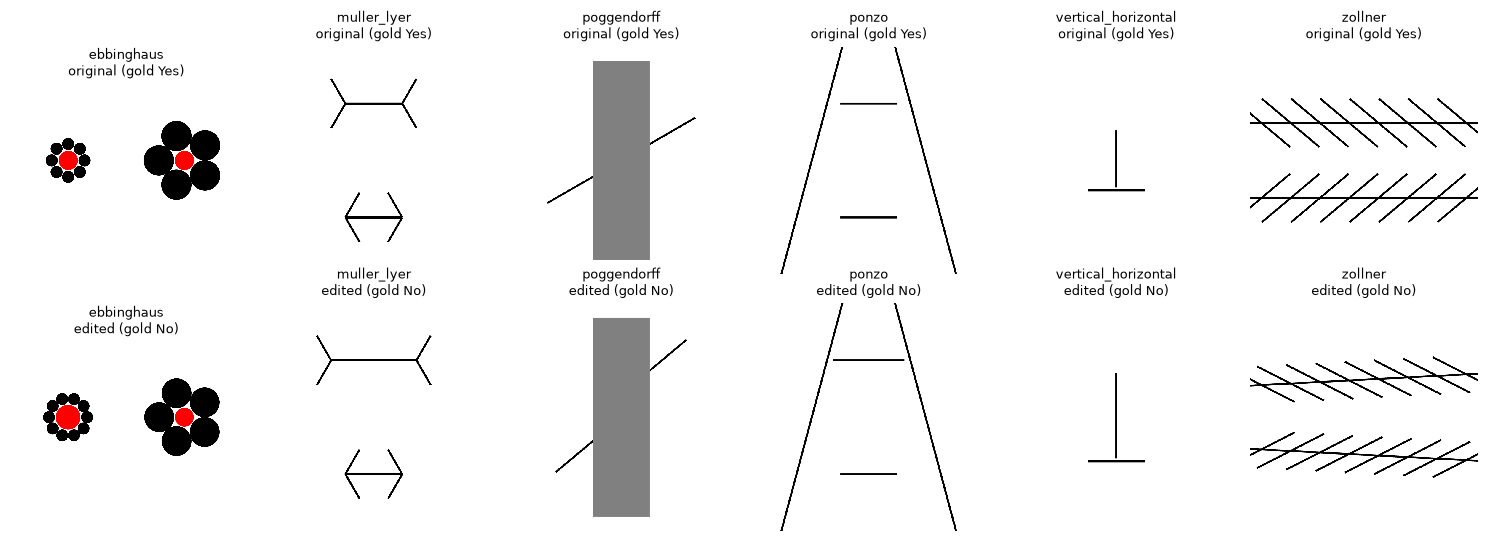

In [3]:
figure, axes = plt.subplots(2, 6, figsize=(15, 5.4))
for number, item in enumerate(picked.itertuples()):
    axis = axes[number % 2][number // 2]
    image = Image.open(DATA / item.image_path).convert("RGB")
    axis.imshow(image, interpolation="nearest")
    axis.set_title(f"{item.gold_illusion}\n{item.condition} (gold {item.gold_answer})", fontsize=9)
    axis.axis("off")
plt.tight_layout()
plt.show()

## 2. The answers

Each row is one call of `Harness.answer(image, question)`. `named` is the output of the first
tool call, `illusion_pixel_rules`. `quantity` is the measured difference that the pipeline gives
to `decide`, and `tolerance` is the frozen limit for that illusion.

In [4]:
answers = {}
rows = []
for item in picked.itertuples():
    image = Image.open(DATA / item.image_path).convert("RGB")
    answer = harness.answer(image, item.prompt_q1)
    answers[item.item_id] = answer
    for step in answer.trace:
        if step.tool == "illusion_pixel_rules":
            named = step.output
    decide_inputs = {}
    for step in answer.trace:
        if step.tool == "decide":
            decide_inputs = step.inputs
    rows.append({
        "illusion": item.gold_illusion,
        "condition": item.condition,
        "intent": answer.intent,
        "confidence": round(answer.confidence, 3),
        "named": named,
        "quantity": round(decide_inputs.get("quantity", float("nan")), 4),
        "tolerance": round(decide_inputs.get("tolerance", float("nan")), 4),
        "value": answer.value,
        "gold": item.gold_answer,
        "right": answer.value == item.gold_answer,
        "tool calls": len(answer.trace),
    })
table = pd.DataFrame(rows)
print("right:", int(table["right"].sum()), "of", len(table))
table

right: 12 of 12


,illusion,condition,intent,confidence,named,quantity,tolerance,value,gold,right,tool calls
0,ebbinghaus,original,structural,1.0,ebbinghaus,0.0000,0.0000,Yes,Yes,True,6
1,ebbinghaus,edited,structural,1.0,ebbinghaus,0.2632,0.0000,No,No,True,6
2,muller_lyer,original,structural,1.0,muller_lyer,0.0302,0.1848,Yes,Yes,True,4
3,muller_lyer,edited,structural,1.0,muller_lyer,0.4130,0.1848,No,No,True,4
4,poggendorff,original,structural,1.0,poggendorff,0.0004,0.0304,Yes,Yes,True,9
5,poggendorff,edited,structural,1.0,poggendorff,-0.3045,0.0304,No,No,True,9
6,ponzo,original,structural,1.0,ponzo,0.0000,0.1765,Yes,Yes,True,4
7,ponzo,edited,structural,1.0,ponzo,0.2222,0.1765,No,No,True,4
8,vertical_horizontal,original,structural,1.0,vertical_horizontal,0.0000,0.0155,Yes,Yes,True,5
9,vertical_horizontal,edited,structural,1.0,vertical_horizontal,0.4000,0.0155,No,No,True,5


## 3. The trace of one image

The edited Ebbinghaus figure: two centre circles of different sizes, each in a ring of circles.
Each row is one tool call inside the structural intent, in order.

In [5]:
item = picked[(picked["gold_illusion"] == "ebbinghaus") & (picked["condition"] == "edited")].iloc[0]
demo.trace_table(answers[item["item_id"]])

,step,tool,inputs,output,ok
0,1,illusion_pixel_rules,image=image 1181x768,'ebbinghaus',True
1,2,colour_mask,"image=image 1181x768, colour='red'","array (768, 1181)",True
2,3,group_shapes,"mask=array (768, 1181), min_pixels=20","[{'pixels': 12296, 'rows': array([321, 321, 321, ..., 446...",True
3,4,equivalent_diameter,"shape={'pixels': 12296, 'rows': array([321,...",125.1230,True
4,5,equivalent_diameter,"shape={'pixels': 7241, 'rows': array([336, ...",96.0184,True
5,6,decide,"quantity=0.2632, tolerance=0.0000",'No',True


## 4. The known miss: Ponzo with the smallest edit

On a Ponzo image with an edit of 0.15, the measured difference is smaller than the frozen
tolerance, so `decide` answers Yes. The answer is binary, so a difference below the tolerance
cannot be reported.

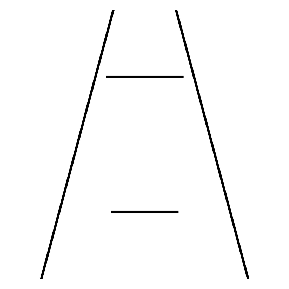

quantity: 0.1449 | tolerance: 0.1765
answer: Yes | gold: No


In [6]:
small = at_768[(at_768["gold_illusion"] == "ponzo") & (at_768["edit_size"] == 0.15)].iloc[0]
image = Image.open(DATA / small["image_path"]).convert("RGB")
answer = harness.answer(image, small["prompt_q1"])

plt.figure(figsize=(3.5, 3.5))
plt.imshow(image, interpolation="nearest")
plt.axis("off")
plt.show()
for step in answer.trace:
    if step.tool == "decide":
        print("quantity:", round(step.inputs["quantity"], 4), "| tolerance:", round(step.inputs["tolerance"], 4))
print("answer:", answer.value, "| gold:", small["gold_answer"])

## Reading the result

(to be written)

## Conclusion

(to be written)